In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12})

RESULTS_DIR = '/workspace/spar-team-recon/projects/ip/results/exp_7'

def load_judgements(arm):
    path = f'{RESULTS_DIR}/{arm}/judgements/three_policies_exp_7.jsonl'
    with open(path) as f:
        rows = [json.loads(line) for line in f if line.strip()]
    data = [r for r in rows if 'overall' not in r]
    summary = [r for r in rows if r.get('overall')][0]
    return data, summary

arms = {
    'arm_0': 'Arm 0 (None, X + Y + Z)',
    'arm_1': 'Arm 1 (X+, X + Y + Z)',
    'arm_2': 'Arm 2 (Y+, X + Y + Z)',
    'arm_3': 'Arm 3 (Z+, X + Y + Z)',
    'arm_4': 'Arm 4 (X-, X + Y + Z)',
    'arm_5': 'Arm 5 (Y-, X + Y + Z)',
    'arm_6': 'Arm 6 (Z-, X + Y + Z)',
}

all_data = {}
all_summaries = {}
for arm in arms:
    all_data[arm], all_summaries[arm] = load_judgements(arm)
    s = all_summaries[arm]
    print(f"{arms[arm]}: comma={s['mean_comma_prob']:.4f}, semi={s['mean_semicolon_prob']:.4f}, fullstop={s['mean_fullstop_prob']:.4f}")

Arm 0 (None, X + Y + Z): comma=0.3278, semi=0.3636, fullstop=0.2567
Arm 1 (X+, X + Y + Z): comma=0.1980, semi=0.5035, fullstop=0.2736
Arm 2 (Y+, X + Y + Z): comma=0.2557, semi=0.4644, fullstop=0.2561
Arm 3 (Z+, X + Y + Z): comma=0.1529, semi=0.6097, fullstop=0.2149
Arm 4 (X-, X + Y + Z): comma=0.3744, semi=0.4072, fullstop=0.1669
Arm 5 (Y-, X + Y + Z): comma=0.0361, semi=0.9472, fullstop=0.0009
Arm 6 (Z-, X + Y + Z): comma=0.0773, semi=0.3712, fullstop=0.5249


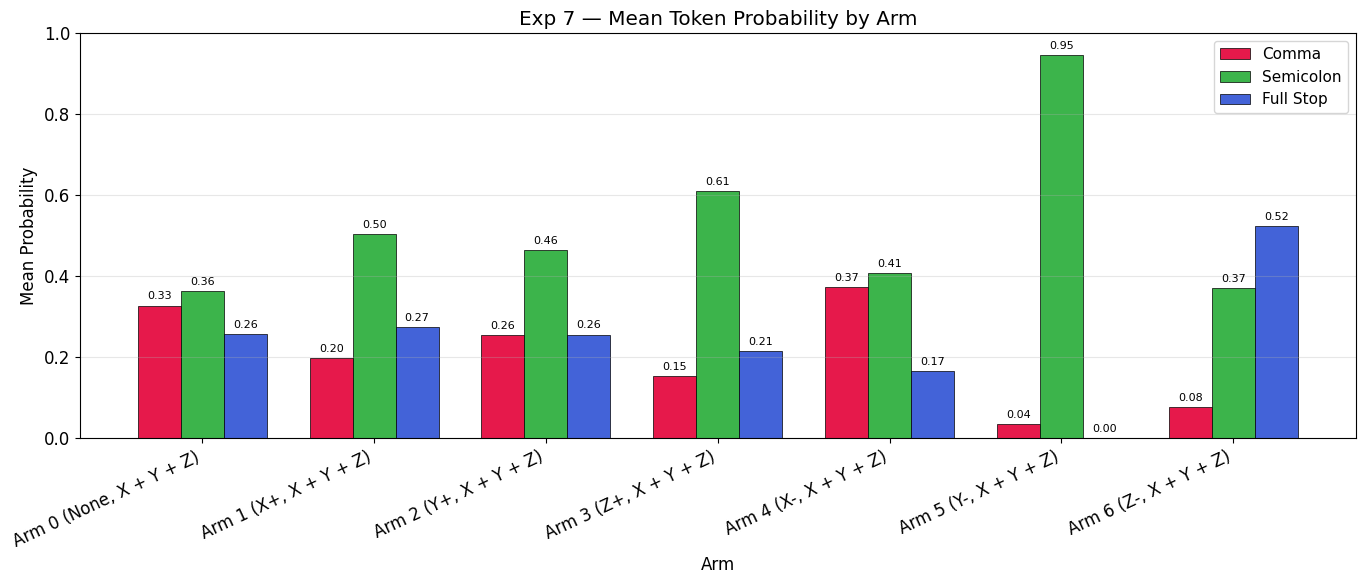

In [2]:
# --- Plot 1: Grouped bar chart of mean probabilities per arm ---
arm_keys = list(arms.keys())
arm_labels = [arms[a] for a in arm_keys]
comma_probs = [all_summaries[a]['mean_comma_prob'] for a in arm_keys]
semi_probs = [all_summaries[a]['mean_semicolon_prob'] for a in arm_keys]
full_probs = [all_summaries[a]['mean_fullstop_prob'] for a in arm_keys]

x = np.arange(len(arm_keys))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, comma_probs, width, label='Comma', color='#e6194B', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, semi_probs, width, label='Semicolon', color='#3cb44b', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, full_probs, width, label='Full Stop', color='#4363d8', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Arm')
ax.set_ylabel('Mean Probability')
ax.set_title('Exp 7 — Mean Token Probability by Arm')
ax.set_xticks(x)
ax.set_xticklabels(arm_labels, rotation=25, ha='right')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

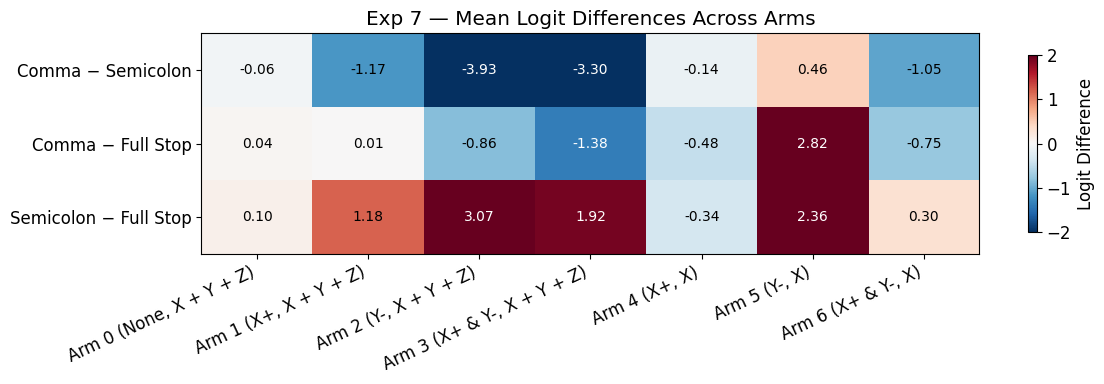

In [3]:
# --- Plot 2: Logit differences heatmap (arm x token-pair) ---
# Shows pairwise logit differences: comma-semi, comma-fullstop, semi-fullstop
arm_keys = list(arms.keys())
arm_labels = [arms[a] for a in arm_keys]

comma_logits = [all_summaries[a]['mean_comma_logit'] for a in arm_keys]
semi_logits = [all_summaries[a]['mean_semicolon_logit'] for a in arm_keys]
full_logits = [all_summaries[a]['mean_fullstop_logit'] for a in arm_keys]

diff_matrix = np.array([
    [c - s for c, s in zip(comma_logits, semi_logits)],      # comma - semicolon
    [c - f for c, f in zip(comma_logits, full_logits)],      # comma - fullstop
    [s - f for s, f in zip(semi_logits, full_logits)],       # semicolon - fullstop
])

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(diff_matrix, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)

ax.set_xticks(range(len(arm_labels)))
ax.set_xticklabels(arm_labels, rotation=25, ha='right')
ax.set_yticks(range(3))
ax.set_yticklabels(['Comma − Semicolon', 'Comma − Full Stop', 'Semicolon − Full Stop'])
ax.set_title('Exp 7 — Mean Logit Differences Across Arms')

# Annotate cells
for i in range(diff_matrix.shape[0]):
    for j in range(diff_matrix.shape[1]):
        val = diff_matrix[i, j]
        color = 'white' if abs(val) > 1.2 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Logit Difference')
plt.tight_layout()
plt.show()

/tmp/ipykernel_8861/480174688.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_arm, patch_artist=True, labels=arm_labels,
/tmp/ipykernel_8861/480174688.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_arm, patch_artist=True, labels=arm_labels,
/tmp/ipykernel_8861/480174688.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_arm, patch_artist=True, labels=arm_labels,


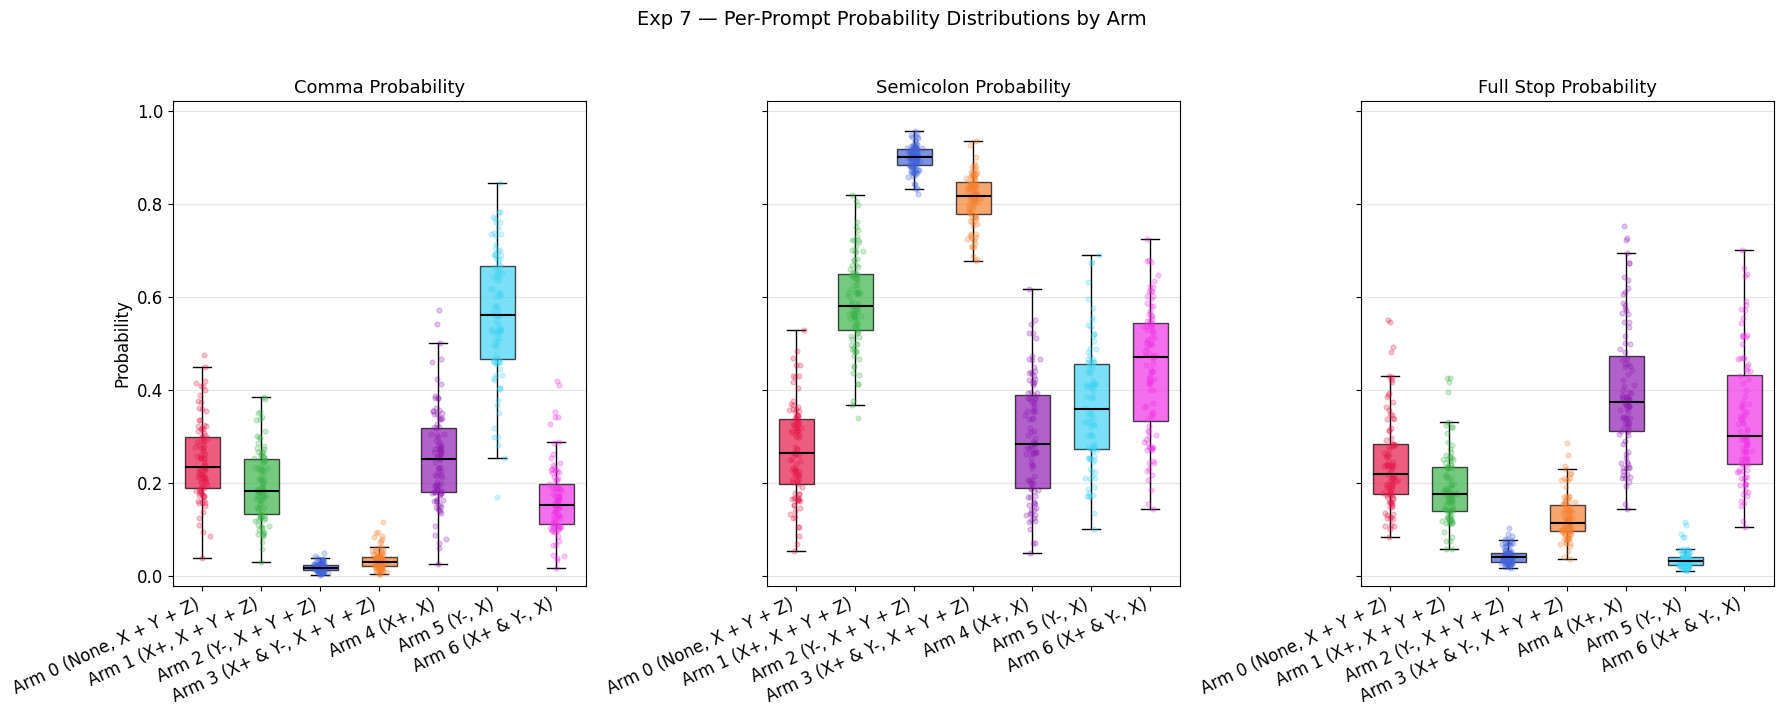

In [4]:
# --- Plot 3: Per-prompt probability distributions (box plots) ---
colors_arms = ['#e6194B', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6']

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
tokens = [
    ('comma_prob', 'Comma'),
    ('semicolon_prob', 'Semicolon'),
    ('fullstop_prob', 'Full Stop'),
]

for ax, (key, title) in zip(axes, tokens):
    data_per_arm = []
    for arm in arm_keys:
        data_per_arm.append([r[key] for r in all_data[arm]])

    bp = ax.boxplot(data_per_arm, patch_artist=True, labels=arm_labels,
                    widths=0.6, showfliers=False, medianprops=dict(color='black', linewidth=1.5))
    for patch, color in zip(bp['boxes'], colors_arms):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Overlay individual points (jittered)
    for i, (arm, color) in enumerate(zip(arm_keys, colors_arms)):
        vals = [r[key] for r in all_data[arm]]
        jitter = np.random.default_rng(42).normal(0, 0.06, len(vals))
        ax.scatter(np.full(len(vals), i + 1) + jitter, vals, alpha=0.25, s=12, color=color, zorder=2)

    ax.set_title(f'{title} Probability', fontsize=13)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(arm_labels, rotation=25, ha='right')

axes[0].set_ylabel('Probability')
fig.suptitle('Exp 7 — Per-Prompt Probability Distributions by Arm', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

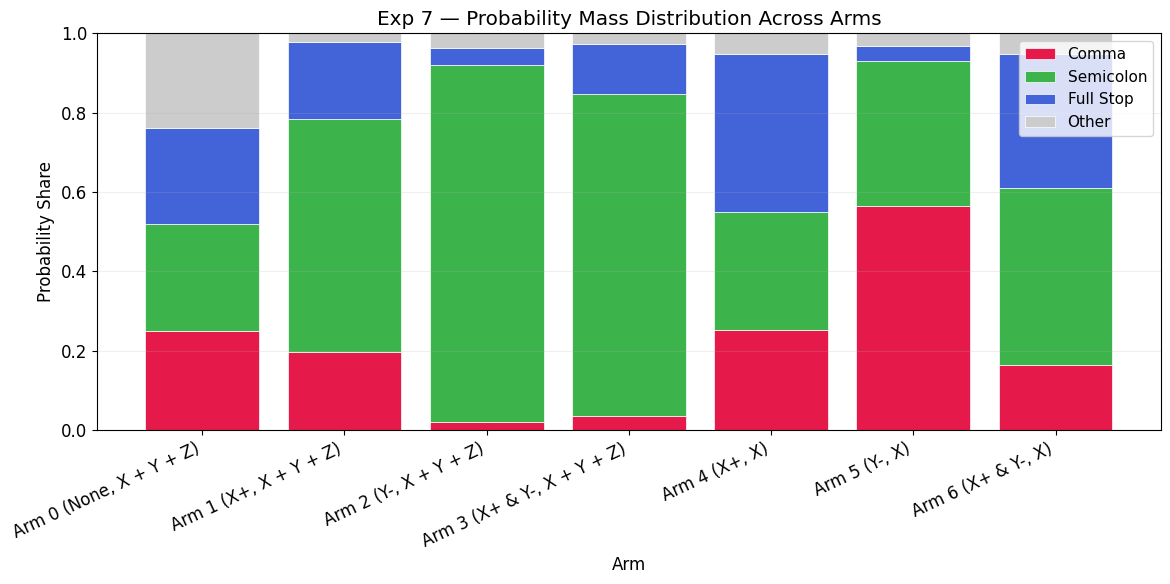

In [5]:
# --- Plot 4: Stacked bar chart showing probability share per arm ---
fig, ax = plt.subplots(figsize=(12, 6))

comma_probs = np.array([all_summaries[a]['mean_comma_prob'] for a in arm_keys])
semi_probs = np.array([all_summaries[a]['mean_semicolon_prob'] for a in arm_keys])
full_probs = np.array([all_summaries[a]['mean_fullstop_prob'] for a in arm_keys])
other_probs = 1.0 - comma_probs - semi_probs - full_probs

x = np.arange(len(arm_keys))

ax.bar(x, comma_probs, label='Comma', color='#e6194B', edgecolor='white', linewidth=0.5)
ax.bar(x, semi_probs, bottom=comma_probs, label='Semicolon', color='#3cb44b', edgecolor='white', linewidth=0.5)
ax.bar(x, full_probs, bottom=comma_probs + semi_probs, label='Full Stop', color='#4363d8', edgecolor='white', linewidth=0.5)
ax.bar(x, other_probs, bottom=comma_probs + semi_probs + full_probs, label='Other', color='#cccccc', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Arm')
ax.set_ylabel('Probability Share')
ax.set_title('Exp 7 — Probability Mass Distribution Across Arms')
ax.set_xticks(x)
ax.set_xticklabels(arm_labels, rotation=25, ha='right')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()